In [11]:
# Data manipulation
import pandas as pd
import numpy as np

# Data visualization
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from IPython.display import display
import missingno as msno

# Import zscore function
from scipy.stats import zscore
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
# Utils
import math
import re
import unicodedata
from pyod.models.mad import MAD

print("Librerías cargadas correctamente")

from utils.functions import *

print("Funciones personalizadas cargadas correctamente")

Librerías cargadas correctamente
Funciones personalizadas cargadas correctamente


In [12]:
paths = {
    "banco_sangre": r"..\data\processed\df_banco_sangre_times_series.csv",
    "defunciones": r"..\data\processed\df_defunciones_sangre_time_series.csv",
    "hospitalizados": r"..\data\processed\df_hospitalizados_time_series.csv",
}

dataframes = {}

for var_name, file in paths.items():
    print(f"Loading data from: {file}")
    try:
        dataframes[var_name] = pd.read_csv(file, low_memory=False)
        print(f"'{var_name}' loaded successfully. Shape: {dataframes[var_name].shape}")
    except FileNotFoundError:
        print(f"Error: File not found → {file}")
        dataframes[var_name] = None
    except pd.errors.EmptyDataError:
        print("Error: The file is empty.")
        dataframes[var_name] = None
    except pd.errors.ParserError:
        print("Error: The file content could not be parsed.")
        dataframes[var_name] = None
    except PermissionError:
        print("Error: Permission denied when accessing the file.")
        dataframes[var_name] = None
    except Exception as e:
        print(f"An unexpected error occurred: {e}")
        dataframes[var_name] = None

# Asignar a variables individuales
df_banco_sangre = dataframes["banco_sangre"]
df_defunciones = dataframes["defunciones"]
df_hospitalizados = dataframes["hospitalizados"]

print("\nDimensiones de los DataFrames:")
print("Banco de Sangre:      ", df_banco_sangre.shape)
print("Defunciones:", df_defunciones.shape)
print("Hospitalizados:", df_hospitalizados.shape)

# Limpiar memoria
del dataframes

Loading data from: ..\data\processed\df_banco_sangre_times_series.csv
'banco_sangre' loaded successfully. Shape: (1321, 2)
Loading data from: ..\data\processed\df_defunciones_sangre_time_series.csv
'defunciones' loaded successfully. Shape: (452, 2)
Loading data from: ..\data\processed\df_hospitalizados_time_series.csv
'hospitalizados' loaded successfully. Shape: (1251, 2)

Dimensiones de los DataFrames:
Banco de Sangre:       (1321, 2)
Defunciones: (452, 2)
Hospitalizados: (1251, 2)


In [13]:
# ── Preparar serie diaria de donaciones ───────────────────────────────────────
df = df_banco_sangre.copy()
df["fecha"] = pd.to_datetime(df["fecha_extraccion"])
df = df.set_index("fecha")["donaciones_diarias"].resample("D").sum()
df = df[df > 0]  # solo días con donaciones

# ── Calcular gaps entre días con donaciones ───────────────────────────────────
fechas = df.index.sort_values()
gaps = pd.DataFrame({
    "inicio": fechas[:-1],
    "fin":    fechas[1:],
})
gaps["dias_sin_donacion"] = (gaps["fin"] - gaps["inicio"]).dt.days - 1

# ── Filtrar gaps mayores a 30 días ────────────────────────────────────────────
gaps_criticos = gaps[gaps["dias_sin_donacion"] > 30].copy()
gaps_criticos["inicio"] = gaps_criticos["inicio"] + pd.Timedelta(days=1)  # primer día sin donación
gaps_criticos = gaps_criticos.reset_index(drop=True)

# ── Resultado ─────────────────────────────────────────────────────────────────
if gaps_criticos.empty:
    print("No hay intervalos de más de 30 días sin donaciones.")
else:
    print(f"Se encontraron {len(gaps_criticos)} intervalo(s) sin donaciones por más de 30 días:\n")
    for _, row in gaps_criticos.iterrows():
        print(f"  Desde {row['inicio'].date()}  →  hasta {row['fin'].date()}  "
              f"({row['dias_sin_donacion']} días)")

Se encontraron 1 intervalo(s) sin donaciones por más de 30 días:

  Desde 2023-12-05  →  hasta 2024-06-12  (190 días)


In [14]:
df_banco_sangre["fecha_extraccion"].max()

'2025-06-27'

In [15]:
df_banco_sangre = df_banco_sangre[df_banco_sangre["fecha_extraccion"].between("2024-06-12", "2025-06-27")]
df_hospitalizados = df_hospitalizados[df_hospitalizados["fecha_atencion"].between("2024-06-12", "2025-06-27")]
df_defunciones = df_defunciones[df_defunciones["fecha_defuncion"].between("2024-06-12", "2025-06-27")]

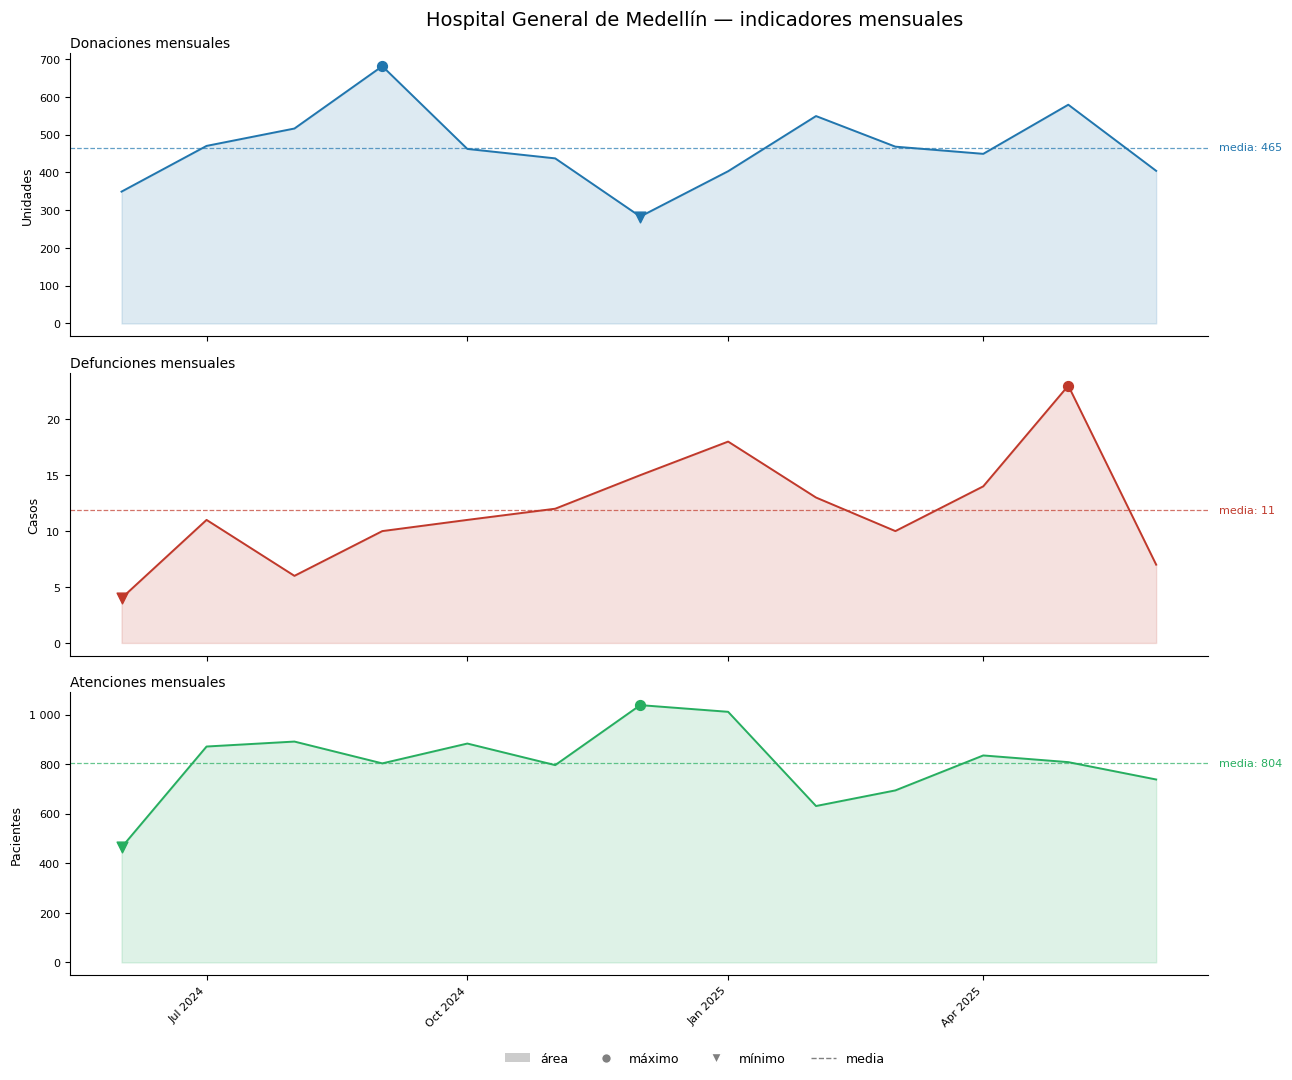

In [16]:
# ── Preparar series ───────────────────────────────────────────────────────────
def preparar_mensual(df, col_fecha, col_valor):
    df = df.copy()
    df = df.set_index(pd.to_datetime(df[col_fecha]))[col_valor].resample("MS").sum().reset_index()
    df.columns = ["fecha", "valor"]
    return df

df_bs   = preparar_mensual(df_banco_sangre,   "fecha_extraccion", "donaciones_diarias")
df_def  = preparar_mensual(df_defunciones,    "fecha_defuncion",  "defunciones_diarias")
df_hosp = preparar_mensual(df_hospitalizados, "fecha_atencion",   "hospitalizaciones_diarias")

# ── Panels ────────────────────────────────────────────────────────────────────
panels = [
    dict(df=df_bs,   title="Donaciones mensuales",  ylabel="Unidades",  color="#2176ae"),
    dict(df=df_def,  title="Defunciones mensuales", ylabel="Casos",     color="#c0392b"),
    dict(df=df_hosp, title="Atenciones mensuales",  ylabel="Pacientes", color="#27ae60"),
]

# ── Figura ────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(14, 11), sharex=True)
fig.suptitle("Hospital General de Medellín — indicadores mensuales", fontsize=14, y=0.98)

for ax, p in zip(axes, panels):
    x, y, col = p["df"]["fecha"], p["df"]["valor"], p["color"]
    media = y.mean()

    ax.fill_between(x, y, alpha=0.15, color=col)
    ax.plot(x, y, color=col, linewidth=1.4)
    ax.axhline(media, color=col, linewidth=0.9, linestyle="--", alpha=0.7)
    ax.annotate(f"media: {int(media):,}".replace(",", " "),
                xy=(1.01, media), xycoords=("axes fraction", "data"),
                va="center", ha="left", fontsize=8, color=col, clip_on=False)
    ax.scatter(x.iloc[y.argmax()], y.iloc[y.argmax()], color=col, s=50, zorder=5)
    ax.scatter(x.iloc[y.argmin()], y.iloc[y.argmin()], color=col, s=60, zorder=5, marker="v")

    ax.set_title(p["title"], loc="left", fontsize=10, pad=4)
    ax.set_ylabel(p["ylabel"], fontsize=9)
    ax.tick_params(labelsize=8)
    ax.spines[["top", "right"]].set_visible(False)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{int(v):,}".replace(",", " ")))

axes[-1].xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1, 4, 7, 10]))
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
plt.setp(axes[-1].xaxis.get_majorticklabels(), rotation=45, ha="right", fontsize=8)

legend_elements = [
    Patch(facecolor="gray", alpha=0.4, label="área"),
    Line2D([0],[0], marker="o", color="w", markerfacecolor="gray", markersize=7, label="máximo"),
    Line2D([0],[0], marker="v", color="w", markerfacecolor="gray", markersize=7, label="mínimo"),
    Line2D([0],[0], color="gray", linewidth=1, linestyle="--", label="media"),
]
fig.legend(handles=legend_elements, loc="lower center", ncol=4, fontsize=9,
           bbox_to_anchor=(0.5, 0.01), frameon=False)

plt.tight_layout(rect=[0, 0.04, 0.93, 1])
plt.show()

In [17]:
# ── Construir dataset de modelado ─────────────────────────────────────────────
DATE_START = "2024-06-12"
DATE_END   = "2025-06-27"

# Rango completo de fechas diarias
idx = pd.date_range(DATE_START, DATE_END, freq="D", name="fecha")

# ── Donaciones diarias ────────────────────────────────────────────────────────
ser_don = (
    df_banco_sangre
    .assign(fecha=pd.to_datetime(df_banco_sangre["fecha_extraccion"]))
    .set_index("fecha")["donaciones_diarias"]
    .resample("D").sum()
    .reindex(idx, fill_value=0)
    .rename("donaciones")
)

# ── Hospitalizados diarios ────────────────────────────────────────────────────
ser_hosp = (
    df_hospitalizados
    .assign(fecha=pd.to_datetime(df_hospitalizados["fecha_atencion"]))
    .set_index("fecha")["hospitalizaciones_diarias"]
    .resample("D").sum()
    .reindex(idx, fill_value=0)
    .rename("hospitalizados")
)

# ── Muertes relacionadas con sangre ──────────────────────────────────────────
ser_muertes = (
    df_defunciones
    .assign(fecha=pd.to_datetime(df_defunciones["fecha_defuncion"]))
    .set_index("fecha")["defunciones_diarias"]
    .resample("D").sum()
    .reindex(idx, fill_value=0)
    .rename("muertes_sangre")
)

# ── Combinar en un solo DataFrame ─────────────────────────────────────────────
df_model = pd.concat([ser_don, ser_hosp, ser_muertes], axis=1).reset_index()

# ── Medias móviles de 7 días ──────────────────────────────────────────────────
df_model["don_media_7d"]  = df_model["donaciones"].rolling(7).mean().round(1)
df_model["hosp_media_7d"] = (
    (df_model["hospitalizados"] + df_model["muertes_sangre"])
    .rolling(7).mean()
    .round(1)
)

# ── Presión diaria y umbral crítico (τ = percentil 75) ────────────────────────
df_model["presion"] = df_model["hosp_media_7d"] - df_model["don_media_7d"]
tau = df_model["presion"].quantile(0.75)

# ── Variable objetivo: escasez en t+14 ───────────────────────────────────────
# shift(-14): en la fila t se pone la presión del día t+14
presion_futura = df_model["presion"].shift(-14)
df_model["escasez_t14"] = (presion_futura > tau).astype("Int64")

# ── Eliminar filas con NaN (primeros 6 días por rolling + últimos 14 por shift)
df_model = df_model.dropna().reset_index(drop=True)
df_model["escasez_t14"] = df_model["escasez_t14"].astype(int)

# ── Resumen ───────────────────────────────────────────────────────────────────
print(f"τ (percentil 75 de presión): {tau:.2f}")
print(f"Shape final:                 {df_model.shape}")
print(f"\nBalance de clases:")
print(df_model["escasez_t14"].value_counts().to_string())
display(df_model.head())


τ (percentil 75 de presión): 18.00
Shape final:                 (375, 8)

Balance de clases:
escasez_t14
0    284
1     91


,fecha,donaciones,hospitalizados,muertes_sangre,don_media_7d,hosp_media_7d,presion,escasez_t14
0,2024-06-18,26,22,0,14.1,25.3,11.2,0
1,2024-06-19,10,37,0,15.3,26.0,10.7,1
2,2024-06-20,19,27,0,14.0,26.4,12.4,1
3,2024-06-21,15,24,0,12.6,25.6,13.0,1
4,2024-06-22,32,25,2,17.1,27.7,10.6,1


In [18]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, ExtraTreesClassifier
from sklearn.metrics import classification_report, roc_auc_score, f1_score
import joblib
import os

# ── Features y target ─────────────────────────────────────────────────────────
FEATURES = ["donaciones", "hospitalizados", "muertes_sangre", "don_media_7d", "hosp_media_7d"]
TARGET   = "escasez_t14"

X = df_model[FEATURES]
y = df_model[TARGET]

# ── Split cronológico 80/20 (sin shuffle — datos de serie temporal) ────────────
split = int(len(df_model) * 0.80)
X_train, X_test = X.iloc[:split], X.iloc[split:]
y_train, y_test = y.iloc[:split], y.iloc[split:]

print(f"Train: {X_train.shape[0]} filas  ({X_train.shape[0]/len(X)*100:.0f}%)")
print(f"Test:  {X_test.shape[0]} filas  ({X_test.shape[0]/len(X)*100:.0f}%)")
print(f"Clases en test → {y_test.value_counts().to_dict()}")


Train: 300 filas  (80%)
Test:  75 filas  (20%)
Clases en test → {0: 68, 1: 7}


In [19]:
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.metrics import recall_score

# ── Pesos para GradientBoosting (no tiene class_weight) ───────────────────────
sw_train = compute_sample_weight("balanced", y_train)

# ── Familia de árboles con class_weight="balanced" ────────────────────────────
modelos = {
    "DecisionTree":      DecisionTreeClassifier(random_state=42, class_weight="balanced"),
    "ExtraTrees":        ExtraTreesClassifier(n_estimators=200, random_state=42, n_jobs=-1, class_weight="balanced"),
    "RandomForest":      RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1, class_weight="balanced"),
    "GradientBoosting":  GradientBoostingClassifier(n_estimators=200, random_state=42),
}

resultados = {}

for nombre, modelo in modelos.items():
    if nombre == "GradientBoosting":
        modelo.fit(X_train, y_train, sample_weight=sw_train)
    else:
        modelo.fit(X_train, y_train)

    y_pred = modelo.predict(X_test)
    y_prob = modelo.predict_proba(X_test)[:, 1]

    resultados[nombre] = {
        "modelo":   modelo,
        "recall":   recall_score(y_test, y_pred),          # recall clase Escasez (objetivo)
        "f1":       f1_score(y_test, y_pred),
        "roc_auc":  roc_auc_score(y_test, y_prob),
    }
    print(f"\n{'─'*50}")
    print(f"  {nombre}")
    print(f"  Recall(Escasez): {resultados[nombre]['recall']:.4f}   F1: {resultados[nombre]['f1']:.4f}   ROC-AUC: {resultados[nombre]['roc_auc']:.4f}")
    print(classification_report(y_test, y_pred, target_names=["Normal", "Escasez"]))

# ── Seleccionar mejor modelo por Recall de clase Escasez ─────────────────────
# Minimizar falsos negativos → maximizar recall en la clase positiva
mejor_nombre = max(resultados, key=lambda k: resultados[k]["recall"])
mejor_modelo = resultados[mejor_nombre]["modelo"]
print(f"\n✔ Mejor modelo (mayor recall en Escasez): {mejor_nombre}")
print(f"   Recall={resultados[mejor_nombre]['recall']:.4f}   F1={resultados[mejor_nombre]['f1']:.4f}   ROC-AUC={resultados[mejor_nombre]['roc_auc']:.4f}")


──────────────────────────────────────────────────
  DecisionTree
  Recall(Escasez): 0.4286   F1: 0.2727   ROC-AUC: 0.6261
              precision    recall  f1-score   support

      Normal       0.93      0.82      0.88        68
     Escasez       0.20      0.43      0.27         7

    accuracy                           0.79        75
   macro avg       0.57      0.63      0.57        75
weighted avg       0.86      0.79      0.82        75


──────────────────────────────────────────────────
  ExtraTrees
  Recall(Escasez): 0.1429   F1: 0.1111   ROC-AUC: 0.5441
              precision    recall  f1-score   support

      Normal       0.91      0.85      0.88        68
     Escasez       0.09      0.14      0.11         7

    accuracy                           0.79        75
   macro avg       0.50      0.50      0.49        75
weighted avg       0.83      0.79      0.81        75


──────────────────────────────────────────────────
  RandomForest
  Recall(Escasez): 0.2857   F1: 0

In [20]:
# ── Guardar mejor modelo ──────────────────────────────────────────────────────
MODELS_DIR = r"..\models"
os.makedirs(MODELS_DIR, exist_ok=True)

model_path = os.path.join(MODELS_DIR, f"best_model_{mejor_nombre.lower()}.pkl")
joblib.dump(mejor_modelo, model_path)

print(f"Modelo guardado en: {model_path}")


Modelo guardado en: ..\models\best_model_decisiontree.pkl


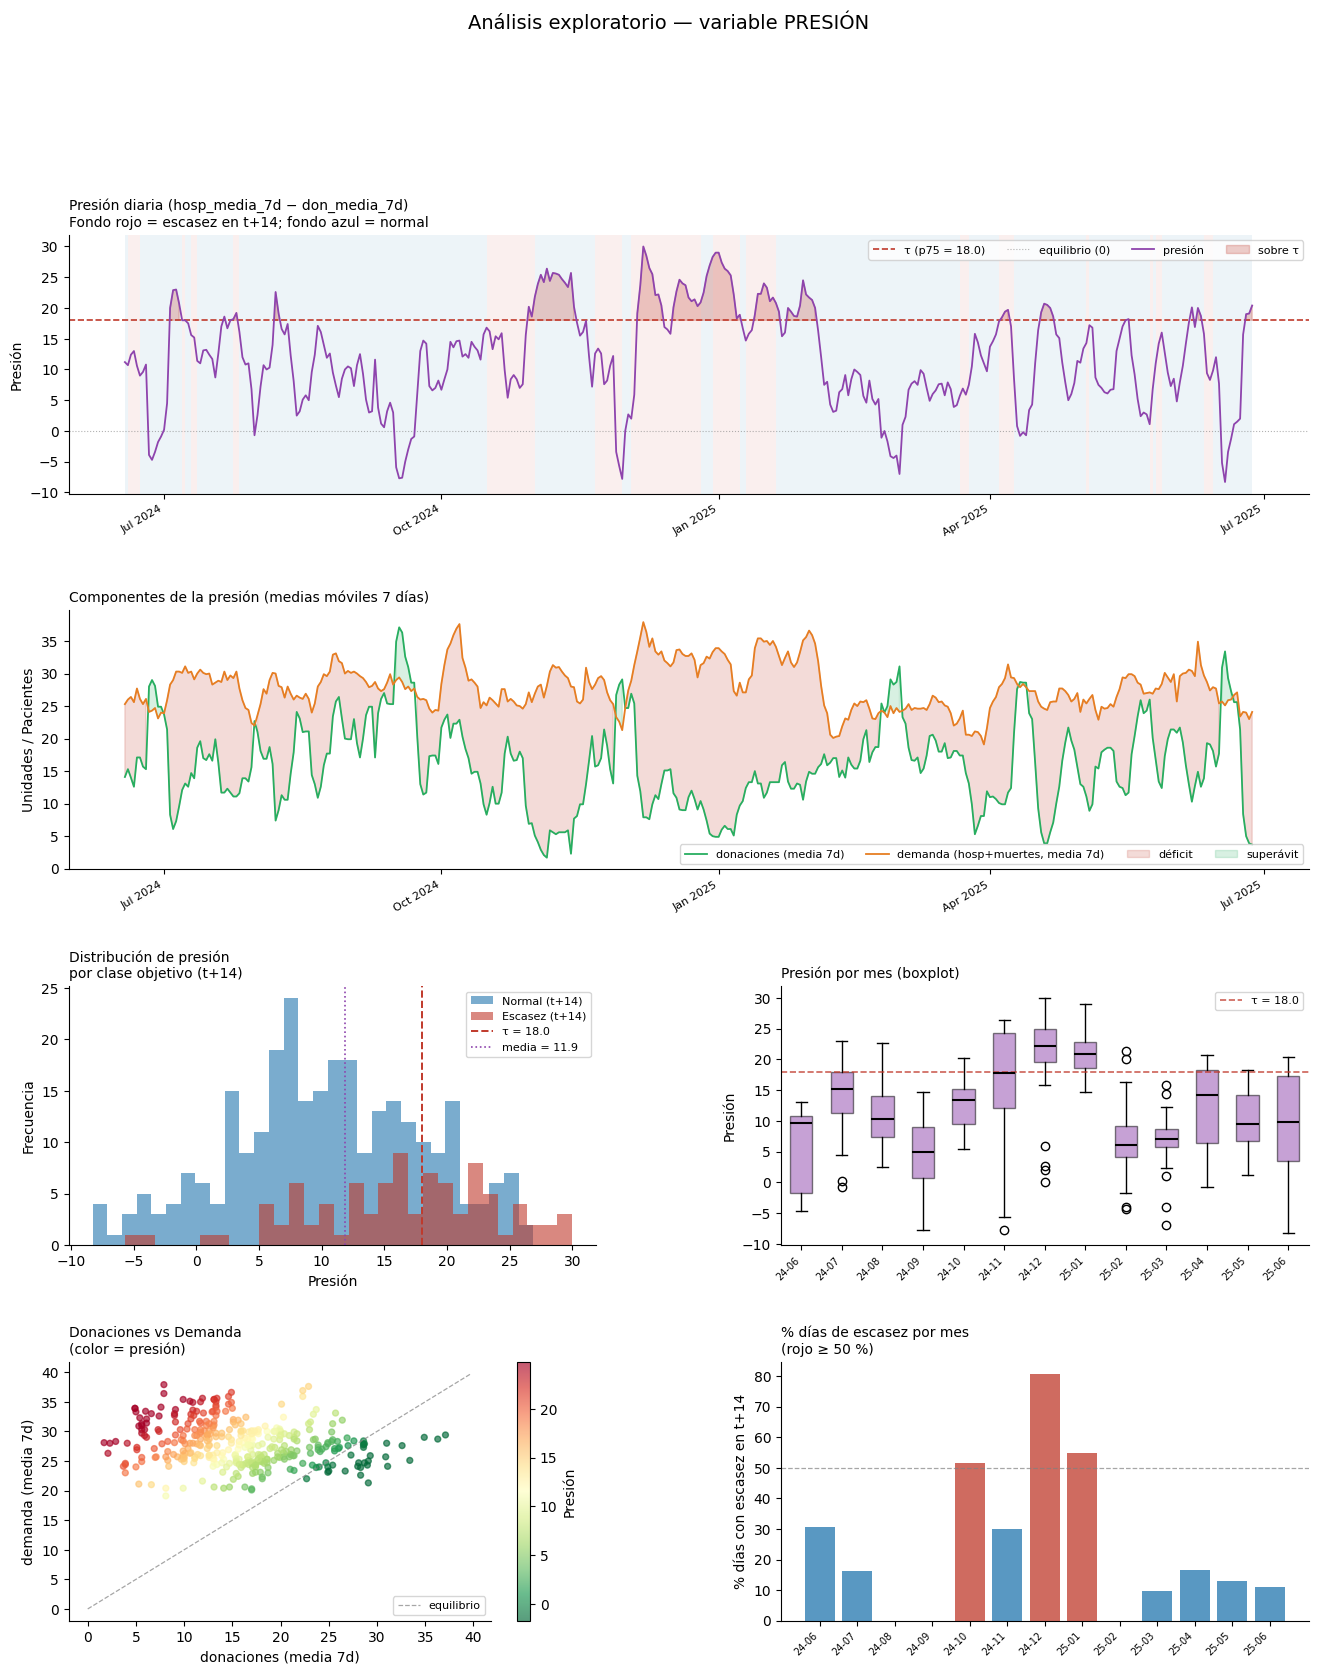

In [21]:

# ── EDA: Análisis visual de la variable 'presion' ─────────────────────────────
fig = plt.figure(figsize=(16, 18))
gs  = fig.add_gridspec(4, 2, hspace=0.45, wspace=0.35)

COLOR_NORMAL  = "#2176ae"
COLOR_ESCASEZ = "#c0392b"
COLOR_DON     = "#27ae60"
COLOR_HOSP    = "#e67e22"
COLOR_PRES    = "#8e44ad"

fechas = df_model["fecha"]

# ── 1. Serie temporal de presión con umbral τ ─────────────────────────────────
ax1 = fig.add_subplot(gs[0, :])
ax1.axhline(tau, color=COLOR_ESCASEZ, linewidth=1.2, linestyle="--", label=f"τ (p75 = {tau:.1f})")
ax1.axhline(0,   color="gray",        linewidth=0.8, linestyle=":",  alpha=0.6, label="equilibrio (0)")

# Colorear fondo según escasez_t14
for i in range(len(df_model) - 1):
    color = COLOR_ESCASEZ if df_model["escasez_t14"].iloc[i] == 1 else COLOR_NORMAL
    ax1.axvspan(fechas.iloc[i], fechas.iloc[i + 1], alpha=0.08, color=color, linewidth=0)

ax1.plot(fechas, df_model["presion"], color=COLOR_PRES, linewidth=1.3, label="presión")
ax1.fill_between(fechas, df_model["presion"], tau,
                 where=df_model["presion"] > tau, alpha=0.25, color=COLOR_ESCASEZ, label="sobre τ")

ax1.set_title("Presión diaria (hosp_media_7d − don_media_7d)\n"
              "Fondo rojo = escasez en t+14; fondo azul = normal", fontsize=10, loc="left")
ax1.set_ylabel("Presión")
ax1.legend(fontsize=8, ncol=4)
ax1.spines[["top", "right"]].set_visible(False)
ax1.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
ax1.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1,4,7,10]))
plt.setp(ax1.xaxis.get_majorticklabels(), rotation=30, ha="right", fontsize=8)

# ── 2. Componentes: don_media_7d vs hosp_media_7d ────────────────────────────
ax2 = fig.add_subplot(gs[1, :])
ax2.plot(fechas, df_model["don_media_7d"],  color=COLOR_DON,  linewidth=1.3, label="donaciones (media 7d)")
ax2.plot(fechas, df_model["hosp_media_7d"], color=COLOR_HOSP, linewidth=1.3, label="demanda (hosp+muertes, media 7d)")
ax2.fill_between(fechas, df_model["don_media_7d"], df_model["hosp_media_7d"],
                 where=df_model["hosp_media_7d"] >= df_model["don_media_7d"],
                 alpha=0.18, color=COLOR_ESCASEZ, label="déficit")
ax2.fill_between(fechas, df_model["don_media_7d"], df_model["hosp_media_7d"],
                 where=df_model["hosp_media_7d"] < df_model["don_media_7d"],
                 alpha=0.18, color=COLOR_DON, label="superávit")
ax2.set_title("Componentes de la presión (medias móviles 7 días)", fontsize=10, loc="left")
ax2.set_ylabel("Unidades / Pacientes")
ax2.legend(fontsize=8, ncol=4)
ax2.spines[["top", "right"]].set_visible(False)
ax2.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
ax2.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1,4,7,10]))
plt.setp(ax2.xaxis.get_majorticklabels(), rotation=30, ha="right", fontsize=8)

# ── 3. Distribución de presión ────────────────────────────────────────────────
ax3 = fig.add_subplot(gs[2, 0])
pres_normal  = df_model.loc[df_model["escasez_t14"] == 0, "presion"]
pres_escasez = df_model.loc[df_model["escasez_t14"] == 1, "presion"]

ax3.hist(pres_normal,  bins=30, alpha=0.6, color=COLOR_NORMAL,  label="Normal (t+14)")
ax3.hist(pres_escasez, bins=30, alpha=0.6, color=COLOR_ESCASEZ, label="Escasez (t+14)")
ax3.axvline(tau,                        color=COLOR_ESCASEZ, linewidth=1.4, linestyle="--", label=f"τ = {tau:.1f}")
ax3.axvline(df_model["presion"].mean(), color=COLOR_PRES,    linewidth=1.2, linestyle=":",  label=f"media = {df_model['presion'].mean():.1f}")
ax3.set_title("Distribución de presión\npor clase objetivo (t+14)", fontsize=10, loc="left")
ax3.set_xlabel("Presión")
ax3.set_ylabel("Frecuencia")
ax3.legend(fontsize=8)
ax3.spines[["top", "right"]].set_visible(False)

# ── 4. Box-plot de presión por mes ────────────────────────────────────────────
ax4 = fig.add_subplot(gs[2, 1])
df_model["mes"] = df_model["fecha"].dt.to_period("M").astype(str)
meses_orden = sorted(df_model["mes"].unique())
data_box = [df_model.loc[df_model["mes"] == m, "presion"].values for m in meses_orden]
bp = ax4.boxplot(data_box, patch_artist=True, widths=0.55, medianprops=dict(color="black", linewidth=1.5))
for patch in bp["boxes"]:
    patch.set_facecolor(COLOR_PRES)
    patch.set_alpha(0.5)
ax4.axhline(tau, color=COLOR_ESCASEZ, linewidth=1.2, linestyle="--", alpha=0.8, label=f"τ = {tau:.1f}")
ax4.set_xticks(range(1, len(meses_orden) + 1))
ax4.set_xticklabels([m[-5:] for m in meses_orden], rotation=45, ha="right", fontsize=7)
ax4.set_title("Presión por mes (boxplot)", fontsize=10, loc="left")
ax4.set_ylabel("Presión")
ax4.legend(fontsize=8)
ax4.spines[["top", "right"]].set_visible(False)

# ── 5. Scatter: donaciones vs demanda, coloreado por presion ─────────────────
ax5 = fig.add_subplot(gs[3, 0])
sc = ax5.scatter(df_model["don_media_7d"], df_model["hosp_media_7d"],
                 c=df_model["presion"], cmap="RdYlGn_r", alpha=0.65, s=18,
                 vmin=df_model["presion"].quantile(0.05),
                 vmax=df_model["presion"].quantile(0.95))
lim = max(df_model["don_media_7d"].max(), df_model["hosp_media_7d"].max()) * 1.05
ax5.plot([0, lim], [0, lim], color="gray", linewidth=0.9, linestyle="--", alpha=0.7, label="equilibrio")
plt.colorbar(sc, ax=ax5, label="Presión")
ax5.set_xlabel("donaciones (media 7d)")
ax5.set_ylabel("demanda (media 7d)")
ax5.set_title("Donaciones vs Demanda\n(color = presión)", fontsize=10, loc="left")
ax5.legend(fontsize=8)
ax5.spines[["top", "right"]].set_visible(False)

# ── 6. Proporción mensual de días en escasez ──────────────────────────────────
ax6 = fig.add_subplot(gs[3, 1])
prop_escasez = (
    df_model.groupby("mes")["escasez_t14"]
    .mean()
    .reindex(meses_orden)
    .mul(100)
)
colores_bar = [COLOR_ESCASEZ if v >= 50 else COLOR_NORMAL for v in prop_escasez]
ax6.bar(range(len(meses_orden)), prop_escasez.values, color=colores_bar, alpha=0.75)
ax6.axhline(50, color="gray", linewidth=0.9, linestyle="--", alpha=0.7)
ax6.set_xticks(range(len(meses_orden)))
ax6.set_xticklabels([m[-5:] for m in meses_orden], rotation=45, ha="right", fontsize=7)
ax6.set_ylabel("% días con escasez en t+14")
ax6.set_title("% días de escasez por mes\n(rojo ≥ 50 %)", fontsize=10, loc="left")
ax6.spines[["top", "right"]].set_visible(False)

fig.suptitle("Análisis exploratorio — variable PRESIÓN", fontsize=14, y=1.005)
plt.show()
